전처리 및 가상ID 처리

In [1]:
import pandas as pd
from tqdm import tqdm

def run_kci_only_ai_preprocessing(node_file, edge_file):
    print("1/4. 데이터 로드 및 AI 시드(Seed) 논문 필터링...")
    df_nodes = pd.read_csv(node_file)
    
    # [조건] 2015년 이후 발간 & 제목 또는 초록에 키워드 포함
    # AI는 대문자만, 나머지는 대소문자 무관
    ai_pattern = r'AI|(?i:Artificial Intelligence|인공지능)'

    mask_ai = (df_nodes['발행연도'] >= 2015) & (
        # 여기서 case=True로 설정해야 패턴 내의 개별 설정이 작동합니다.
        df_nodes['제목'].str.contains(ai_pattern, case=True, na=False) | 
        df_nodes['초록'].str.contains(ai_pattern, case=True, na=False)
    )
    
    ai_seed_df = df_nodes[mask_ai].copy()
    ai_seed_ids = set(ai_seed_df['논문ID'].unique())
    all_kci_ids = set(df_nodes['논문ID'].unique()) # 전체 KCI 논문 ID 집합
    
    print(f"   -> AI 시드 논문 선정: {len(ai_seed_ids)}편")

    print("2/4. 인용 엣지 필터링 (KCI to KCI)...")
    df_edges = pd.read_csv(edge_file)
    
    # 필터링 규칙:
    # 1. 인용을 한 논문(source_id)이 AI 시드 논문이어야 함
    # 2. 인용을 당한 논문(target_arti_id)이 KCI ID를 가지고 있어야 함
    # 3. 그 target_arti_id가 실제로 노드 리스트(KCI)에 존재해야 함
    
    mask_kci_to_kci = (
        df_edges['source_id'].isin(ai_seed_ids) & 
        df_edges['target_arti_id'].notna() & 
        df_edges['target_arti_id'].isin(all_kci_ids)
    )
    
    final_edges = df_edges[mask_kci_to_kci].copy()
    # 컬럼명 통일
    final_edges = final_edges.rename(columns={'target_arti_id': 'target_id_final'})
    
    print(f"   -> 필터링된 KCI 간 인용 관계 수: {len(final_edges)}")

    print("3/4. 최종 분석 대상 노드 리스트 정리...")
    # 엣지에 등장하는 모든 논문 ID (Source + Target)|
    active_node_ids = set(final_edges['source_id'].unique()) | set(final_edges['target_id_final'].unique())
    
    # 노드 메타데이터 추출
    final_nodes = df_nodes[df_nodes['논문ID'].isin(active_node_ids)].copy()
    final_nodes = final_nodes.rename(columns={'논문ID': 'node_id'})
    
    print("4/4. KCI 전용 AI 데이터 저장 중...")
    # 최종 결과물 저장
    final_edges[['source_id', 'target_id_final', 'ref_type']].to_csv('KCI_AI_전용_인용_엣지.csv', index=False, encoding='utf-8-sig')
    final_nodes[['node_id', '발행연도', '제목', '저자', '학술지명']].to_csv('KCI_AI_전용_논문_노드.csv', index=False, encoding='utf-8-sig')

    print(f"\n✅ KCI 전용 정제 완료!")
    print(f"- 최종 노드 수: {len(final_nodes)}개")
    print(f"- 최종 엣지 수: {len(final_edges)}개")

if __name__ == "__main__":
    run_kci_only_ai_preprocessing('전체_법학_논문목록_정제본.csv', '법학_인용_네트워크_데이터_전체.csv')

1/4. 데이터 로드 및 AI 시드(Seed) 논문 필터링...
   -> AI 시드 논문 선정: 2113편
2/4. 인용 엣지 필터링 (KCI to KCI)...
   -> 필터링된 KCI 간 인용 관계 수: 11621
3/4. 최종 분석 대상 노드 리스트 정리...
4/4. KCI 전용 AI 데이터 저장 중...

✅ KCI 전용 정제 완료!
- 최종 노드 수: 5743개
- 최종 엣지 수: 11621개


In [ ]:
# import pandas as pd

# # 1. 데이터 로드
# nodes = pd.read_csv('정제된_논문_노드_목록.csv')
# edges = pd.read_csv('정제된_인용_엣지_목록.csv')

# # 2. KCI 논문 ID 리스트 추출 (90,196개)
# kci_node_ids = set(nodes[nodes['node_type'] == 'KCI']['node_id'].unique())

# # 3. 엣지 필터링 (Source와 Target이 모두 KCI 리스트에 있는 경우만 남김)
# # 즉, '국내 법학 논문이 국내 법학 논문을 인용한 관계'만 분석
# clean_edges = edges[
#     edges['source_id'].isin(kci_node_ids) & 
#     edges['target_id_final'].isin(kci_node_ids)
# ].copy()

# # 4. 사용되지 않는 가상 ID 노드 제거
# clean_nodes = nodes[nodes['node_id'].isin(kci_node_ids)].copy()

# # 5. 최종 데이터 저장
# clean_edges.to_csv('KCI_전용_인용_엣지.csv', index=False, encoding='utf-8-sig')
# clean_nodes.to_csv('KCI_전용_논문_노드.csv', index=False, encoding='utf-8-sig')

# print(f"✅ 필터링 완료!")
# print(f"- 남은 노드(KCI): {len(clean_nodes)}개")
# print(f"- 남은 엣지(KCI-to-KCI): {len(clean_edges)}개")

KeyError: 'node_type'

In [ ]:
# # 중복된 ID가 있는지 확인
# duplicate_ids = df_nodes['node_id'].duplicated().sum()
# print(f"중복된 노드 ID 수: {duplicate_ids}")

# # 만약 있다면 제거
# if duplicate_ids > 0:
#     df_nodes = df_nodes.drop_duplicates(subset='node_id')

In [ ]:
# # 완벽하게 동일한 엣지 행 확인 및 제거
# duplicate_edges = df_edges.duplicated(subset=['source_id', 'target_id_final']).sum()
# print(f"중복된 엣지 수: {duplicate_edges}")

# df_edges = df_edges.drop_duplicates(subset=['source_id', 'target_id_final'])

In [ ]:
# # 가상 ID 노드들만 따로 뽑아 빈도 확인
# ext_nodes = df_edges[df_edges['target_id_final'].str.startswith('EXT_', na=False)]
# print(f"전체 가상 ID 노드 수: {ext_nodes['target_id_final'].nunique()}")

# # 상위 10개 출력해서 실제로 잘 묶였는지 확인
# print(ext_nodes['raw_citation'].value_counts().head(10))

In [ ]:
# # 1. 원본 데이터 로드
# nodes = pd.read_csv('정제된_논문_노드_목록.csv')
# edges = pd.read_csv('정제된_인용_엣지_목록.csv')

# # 2. 고유성 체크
# print(f"1. 전체 노드 행 수: {len(nodes)}")
# print(f"2. 고유 노드 ID 수: {nodes['node_id'].nunique()}") # 1번과 2번이 다르면 문제!

# print(f"3. 전체 엣지 행 수: {len(edges)}")
# unique_edges = edges.groupby(['source_id', 'target_id_final']).size().reset_index().shape[0]
# print(f"4. 고유 엣지(중복제거) 수: {unique_edges}") # 3번과 4번이 차이가 크면 문제!

# # 3. 연도별 분포 체크 (특정 연도에 쏠림이 있는지)
# edges_with_year = edges.merge(nodes[['node_id', '발행연도']], left_on='source_id', right_on='node_id', how='left')
# print("\n[연도별 엣지 분포]")
# print(edges_with_year['발행연도'].value_counts().sort_index())

In [ ]:
# import pandas as pd

# # 1. 정제된 데이터 로드
# nodes = pd.read_csv('정제된_논문_노드_목록.csv')
# edges = pd.read_csv('정제된_인용_엣지_목록.csv')

# print("--- [1. 데이터 규모 점검] ---")
# print(f"전체 노드(행): {len(nodes)}건")
# print(f"고유 노드 ID(Unique): {nodes['node_id'].nunique()}건")
# print(f"전체 엣지(행): {len(edges)}건")
# print(f"고유 엣지(Source-Target 조합): {edges.groupby(['source_id', 'target_id_final']).size().shape[0]}건")

# print("\n--- [2. 노드 타입별 분포] ---")
# print(nodes['node_type'].value_counts())

# print("\n--- [3. 가상 ID(EXT_) 생성 현황 점검] ---")
# # 비 KCI 문헌들(제목 컬럼에 원본 텍스트가 들어있음) 상위 인용 확인
# ext_node_ids = nodes[nodes['node_type'] == 'NON-KCI']['node_id']
# ext_edges = edges[edges['target_id_final'].isin(ext_node_ids)]

# # 어떤 문헌이 가장 많이 인용되었는지 확인 (제목 매칭)
# top_ext_citations = ext_edges['target_id_final'].value_counts().head(10)
# top_ext_info = pd.DataFrame(top_ext_citations).reset_index()
# top_ext_info.columns = ['node_id', 'count']
# top_ext_info = top_ext_info.merge(nodes[['node_id', '제목']], on='node_id')

# print("인용 상위 10개 비 KCI 문헌:")
# print(top_ext_info[['제목', 'count']])

# print("\n--- [4. 연도별 엣지(인용) 발생량] ---")
# # 엣지에 발행연도 붙여서 확인
# edges_with_year = edges.merge(nodes[['node_id', '발행연도']], left_on='source_id', right_on='node_id', how='left')
# year_counts = edges_with_year['발행연도'].value_counts().sort_index()
# print(year_counts)

# 분절분석

In [2]:
import pandas as pd
import networkx as nx
from tqdm import tqdm

# 1. 데이터 로드
df_nodes = pd.read_csv('KCI_AI_전용_논문_노드.csv')
df_edges = pd.read_csv('KCI_AI_전용_인용_엣지.csv')

# 2. 분석을 위해 엣지 데이터에 Source 논문의 발행연도 매칭
df_edges = df_edges.merge(df_nodes[['node_id', '발행연도']], left_on='source_id', right_on='node_id', how='left')

def analyze_discrete_network(start_year=2015, end_year=2024):
    yearly_metrics = []
    
    for year in tqdm(range(start_year, end_year + 1), desc="연도별 지표 계산 중"):
        # --- [추가 코드] 해당 연도에 실제로 '발행'된 논문 숫자 계산 ---
        num_papers_published = len(df_nodes[df_nodes['발행연도'] == year])
        
        # 해당 연도에 발행된 논문들이 생성한 엣지만 추출
        year_edges = df_edges[df_edges['발행연도'] == year]
        
        if year_edges.empty:
            # 엣지가 없더라도 발행 논문 수는 기록하기 위해 처리
            yearly_metrics.append({
                '연도': year,
                '발행논문수': num_papers_published,
                '네트워크_노드수': 0,
                '엣지수': 0,
                '밀도': 0,
                '주요논문': "데이터 없음"
            })
            continue
            
        # 그래프 생성
        G = nx.DiGraph()
        G.add_edges_from(zip(year_edges['source_id'], year_edges['target_id_final']))
        
        # 지표 계산
        num_nodes = G.number_of_nodes() # 네트워크에 포함된 논문 수 (인용한 논문 + 인용된 논문)
        num_edges = G.number_of_edges()
        density = nx.density(G)
        
        # 인차수(In-degree) 상위 논문 추출
        in_degrees = dict(G.in_degree())
        top_nodes = sorted(in_degrees.items(), key=lambda x: x[1], reverse=True)[:3]
        
        top_titles = []
        for node_id, count in top_nodes:
            title_info = df_nodes[df_nodes['node_id'] == node_id]['제목']
            title = title_info.values[0] if not title_info.empty else "Unknown"
            top_titles.append(f"{title}({count}회)")
            
        yearly_metrics.append({
            '연도': year,
            '발행논문수': num_papers_published,  # 추가된 지표
            '네트워크_노드수': num_nodes,
            '엣지수': num_edges,
            '밀도': round(density, 5),
            '주요논문': ", ".join(top_titles)
        })
        
    return pd.DataFrame(yearly_metrics)

# 분석 실행
discrete_results = analyze_discrete_network()
discrete_results.to_csv('연도별_분절분석_결과.csv', index=False, encoding='utf-8-sig')

print("\n📊 연도별 주요 지표 요약 (발행논문수 포함):")
print(discrete_results[['연도', '발행논문수', '네트워크_노드수', '엣지수', '밀도']])

연도별 지표 계산 중: 100%|██████████| 10/10 [00:00<00:00, 193.24it/s]


📊 연도별 주요 지표 요약 (발행논문수 포함):
     연도  발행논문수  네트워크_노드수   엣지수       밀도
0  2015    286        79    68  0.01104
1  2016    368       218   224  0.00474
2  2017    430       453   527  0.00257
3  2018    462       581   732  0.00217
4  2019    435       646   763  0.00183
5  2020    473      1071  1394  0.00122
6  2021    462      1314  1677  0.00097
7  2022    425      1125  1455  0.00115
8  2023    378      1540  2043  0.00086
9  2024    386      1951  2738  0.00072


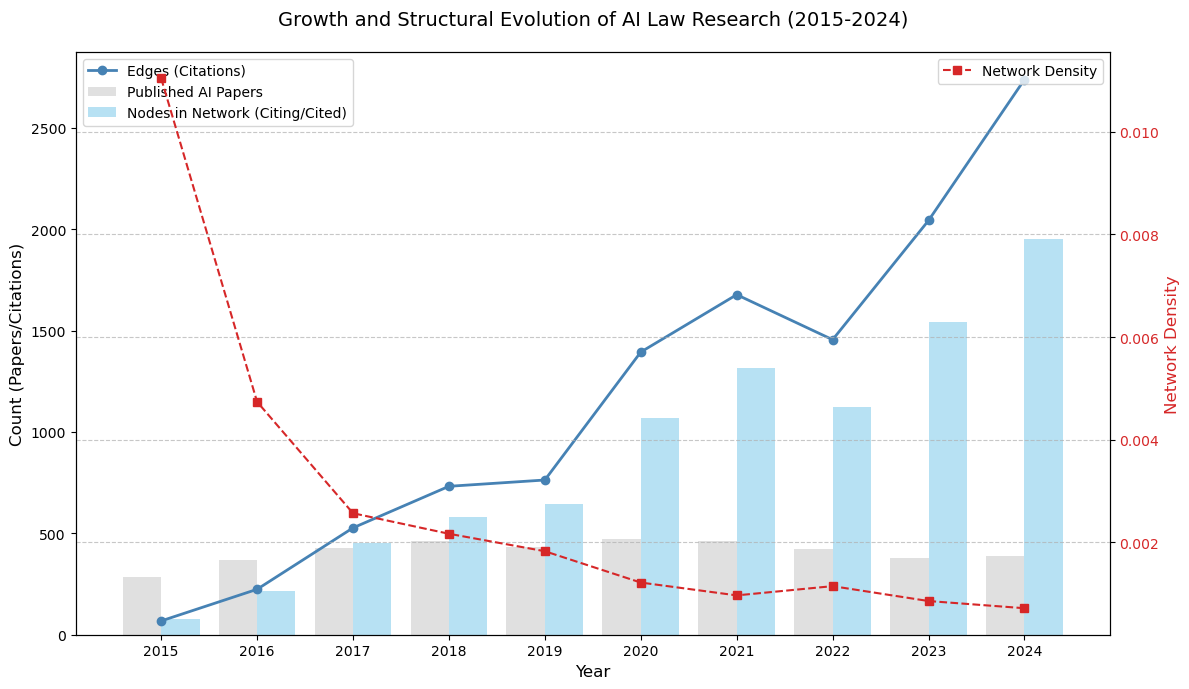

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. 분석 결과 데이터 로드
df = pd.read_csv('연도별_분절분석_결과.csv')

# 2. 시각화 (이중 축 활용)
fig, ax1 = plt.subplots(figsize=(12, 7))

# 축 1: 발행논문수 및 네트워크 노드수 (Bar)
# 두 데이터를 나란히 보여주기 위해 바 차트를 겹치거나 나열할 수 있습니다.
ax1.bar(df['연도'] - 0.2, df['발행논문수'], width=0.4, color='lightgray', alpha=0.7, label='Published AI Papers')
ax1.bar(df['연도'] + 0.2, df['네트워크_노드수'], width=0.4, color='skyblue', alpha=0.6, label='Nodes in Network (Citing/Cited)')

# 축 1: 엣지수 (Line) - 인용 관계의 총량
ax1.plot(df['연도'], df['엣지수'], color='steelblue', marker='o', linewidth=2, label='Edges (Citations)')

ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Count (Papers/Citations)', fontsize=12)
ax1.set_xticks(df['연도'])
ax1.legend(loc='upper left')

# 축 2: 밀도 (Secondary Y-axis)
ax2 = ax1.twinx()
ax2.plot(df['연도'], df['밀도'], color='tab:red', marker='s', linestyle='--', label='Network Density')
ax2.set_ylabel('Network Density', color='tab:red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.legend(loc='upper right')

# 그래프 제목 및 설정
plt.title('Growth and Structural Evolution of AI Law Research (2015-2024)', fontsize=14, pad=20)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 레이아웃 조정 및 저장
plt.tight_layout()
plt.savefig('AI_law_discrete_trends_updated.png', dpi=300)
plt.show()

In [ ]:
# import pandas as pd
# import networkx as nx
# import community.community_louvain as louvain
# from collections import Counter

# # 1. 데이터 로드
# df_nodes = pd.read_csv('KCI_전용_논문_노드.csv')
# df_edges = pd.read_csv('KCI_전용_인용_엣지.csv')

# # 2. 엣지 데이터에 발행연도 매칭
# df_edges = df_edges.merge(df_nodes[['node_id', '발행연도']], left_on='source_id', right_on='node_id', how='left')

# def analyze_discrete_community(start_year=2016, end_year=2024):
#     yearly_summary = []
#     top_10_details = []
    
#     for year in range(start_year, end_year + 1):
#         # 해당 연도에 발행된 논문의 인용 엣지만 추출
#         year_edges = df_edges[df_edges['발행연도'] == year]
#         if year_edges.empty: continue
            
#         # 그래프 생성 (영향력 계산용 DiGraph, 커뮤니티 탐지용 Graph)
#         G_dir = nx.DiGraph()
#         G_dir.add_edges_from(zip(year_edges['source_id'], year_edges['target_id_final']))
#         G_undir = G_dir.to_undirected()
        
#         # 1. 커뮤니티 탐지
#         partition = louvain.best_partition(G_undir)
#         modularity = louvain.modularity(partition, G_undir)
        
#         # 2. 상위 10개 논문 추출 (In-degree 기준)
#         in_degrees = dict(G_dir.in_degree())
#         top_10_nodes = sorted(in_degrees.items(), key=lambda x: x[1], reverse=True)[:10]
        
#         for rank, (node_id, count) in enumerate(top_10_nodes, 1):
#             paper_info = df_nodes[df_nodes['node_id'] == node_id]
#             if not paper_info.empty:
#                 top_10_details.append({
#                     '분석연도': year,
#                     '순위': rank,
#                     '인용수': count,
#                     '제목': paper_info['제목'].values[0],
#                     '커뮤니티ID': partition.get(node_id, -1)
#                 })
        
#         # 3. 연도별 요약 지표
#         yearly_summary.append({
#             '연도': year,
#             '노드수': G_undir.number_of_nodes(),
#             '엣지수': G_undir.number_of_edges(),
#             '모듈러리티(Q)': round(modularity, 4),
#             '커뮤니티수': len(set(partition.values())),
#             '가장큰그룹크기': Counter(partition.values()).most_common(1)[0][1] if partition else 0
#         })
        
#     return pd.DataFrame(yearly_summary), pd.DataFrame(top_10_details)

# # 실행 및 저장
# summary_df, top10_df = analyze_discrete_community()
# summary_df.to_csv('연도별_분절_요약지표.csv', index=False, encoding='utf-8-sig')
# top10_df.to_csv('연도별_분절_상위10_추적.csv', index=False, encoding='utf-8-sig')

# print("📊 연도별 분절 분석 요약 (커뮤니티 포함):")
# print(summary_df[['연도', '노드수', '모듈러리티(Q)', '커뮤니티수']])

### '해당 연도에 작성된 논문들이' 인용한 논문들 중에서 가장 중요한 것}

In [4]:
import pandas as pd
import networkx as nx

# 1. 필터링된 KCI 전용 데이터 로드
nodes = pd.read_csv('KCI_AI_전용_논문_노드.csv')
edges = pd.read_csv('KCI_AI_전용_인용_엣지.csv')

# 2. 연도별 Top 5 추출 함수
def get_yearly_top_authorities(start_year=2015, end_year=2024):
    all_top_papers = []
    
    for year in range(start_year, end_year + 1):
        # 해당 연도에 발행된 논문들이 인용한 데이터 필터링
        year_edges = edges.merge(nodes[['node_id', '발행연도']], left_on='source_id', right_on='node_id')
        year_edges = year_edges[year_edges['발행연도'] == year]
        
        if year_edges.empty: continue
        
        # 그래프 생성 및 인용 횟수 계산
        G = nx.DiGraph()
        G.add_edges_from(zip(year_edges['source_id'], year_edges['target_id_final']))
        
        in_degrees = dict(G.in_degree())
        # 상위 5개 추출
        top_5 = sorted(in_degrees.items(), key=lambda x: x[1], reverse=True)[:5]
        
        for rank, (node_id, count) in enumerate(top_5, 1):
            # 노드 정보 가져오기
            info = nodes[nodes['node_id'] == node_id]
            if not info.empty:
                title = info['제목'].values[0]
                author = info['저자'].values[0]
                pub_year = info['발행연도'].values[0]
                
                all_top_papers.append({
                    '분석연도': year,
                    '순위': rank,
                    '인용수': count,
                    '논문제목': title,
                    '저자': author,
                    '논문발행일': int(pub_year) if pd.notna(pub_year) else "N/A"
                })
                
    return pd.DataFrame(all_top_papers)

# 실행 및 결과 저장
top_papers_df = get_yearly_top_authorities()
top_papers_df.to_csv('연도별_핵심_논문_리스트.csv', index=False, encoding='utf-8-sig')

# 결과 확인 (예시로 최근 2년만 출력)
print(top_papers_df[top_papers_df['분석연도'] >= 2023])

    분석연도  순위  인용수                                               논문제목  \
40  2023   1   10                                    인공지능시대의 저작권법 과제   
41  2023   2   10              인공지능 창작물의 저작권법상 보호 쟁점에 대한 개정방안에 관한 연구   
42  2023   3    9                             생성형 인공지능(AI) 모델의 법률 문제   
43  2023   4    9                            인공지능 로봇은 법인격을 가질 수 있는가?   
44  2023   5    9                             인공지능 로봇에 의한 손해의 불법행위책임   
45  2024   1   14                         人工知能(로봇)의 법적 쟁점에 대한 試論的 考察   
46  2024   2   12  생성형 인공지능(Generative AI) 기술의 규제 방향에 대한 입법론적 고찰 ...   
47  2024   3   11                               인공지능(AI) 생성물과 저작권 문제   
48  2024   4   11                                   인공지능 창작물의 저작권 보호   
49  2024   5   10                          유럽연합 ‘인공지능법안’의 주요 내용과 시사점   

                                              저자  논문발행일  
40                                    정상조(서울대학교)   2018  
41                                    차상육(경북대학교)   2020  
42                               

In [5]:
# import pandas as pd
# import networkx as nx
# import community.community_louvain as louvain # python-louvain
# from collections import Counter

# # 1. 데이터 로드
# nodes = pd.read_csv('KCI_전용_논문_노드.csv')
# edges = pd.read_csv('KCI_전용_인용_엣지.csv')
# edges = edges.merge(nodes[['node_id', '발행연도']], left_on='source_id', right_on='node_id')

# def analyze_communities(start_year=2016, end_year=2024):
#     community_history = []
    
#     for year in range(start_year, end_year + 1):
#         # 해당 연도의 무방향 그래프 생성 (Louvain은 무방향성에서 더 안정적)
#         year_edges = edges[edges['발행연도'] <= year] # 누적식 커뮤니티 탐지 권장
#         G = nx.Graph()
#         G.add_edges_from(zip(year_edges['source_id'], year_edges['target_id_final']))
        
#         if G.number_of_nodes() < 2: continue
        
#         # Louvain 알고리즘 적용
#         partition = louvain.best_partition(G)
        
#         # 지표 계산
#         modularity = louvain.modularity(partition, G)
#         num_communities = len(set(partition.values()))
        
#         # 커뮤니티별 크기 확인
#         counts = Counter(partition.values())
#         major_communities = counts.most_common(3) # 가장 큰 3개 그룹
        
#         community_history.append({
#             '연도': year,
#             '모듈러리티(Q)': round(modularity, 4),
#             '커뮤니티수': num_communities,
#             '가장큰그룹크기': major_communities[0][1] if major_communities else 0
#         })
        
#         # (옵션) 2024년 결과에서 각 커뮤니티별 핵심 키워드/논문 추출 가능
#         if year == 2024:
#             nodes['community'] = nodes['node_id'].map(partition)
            
#     return pd.DataFrame(community_history), nodes

# # 실행
# history_df, nodes_with_comm = analyze_communities()
# history_df.to_csv('연도별_커뮤니티_지표.csv', index=False, encoding='utf-8-sig')

# print("📊 커뮤니티 형성 추이:")
# print(history_df)

In [6]:
# import pandas as pd

# def get_community_representatives(nodes_df, edges_df, top_n=5):
#     """
#     각 커뮤니티별로 인용 수가 가장 많은 대표 논문을 추출합니다.
#     """
#     # 1. 전체 네트워크에서의 인용 횟수(In-degree) 계산
#     citation_counts = edges_df['target_id_final'].value_counts().reset_index()
#     citation_counts.columns = ['node_id', 'citation_count']
    
#     # 2. 노드 데이터와 인용 횟수 및 커뮤니티 정보 병합
#     # nodes_df에는 이미 'community' 컬럼이 포함되어 있어야 합니다.
#     results = nodes_df.merge(citation_counts, on='node_id', how='left')
#     results['citation_count'] = results['citation_count'].fillna(0)
    
#     representative_list = []
    
#     # 3. 각 커뮤니티별로 루프를 돌며 상위 논문 추출
#     unique_communities = sorted(results['community'].dropna().unique())
    
#     for comm_id in unique_communities:
#         comm_papers = results[results['community'] == comm_id]
        
#         # 커뮤니티 규모가 너무 작으면 제외 (선택 사항)
#         if len(comm_papers) < 5:
#             continue
            
#         # 인용 수 기준 내림차순 정렬 후 상위 N개 선택
#         top_papers = comm_papers.sort_values(by='citation_count', ascending=False).head(top_n)
        
#         for _, row in top_papers.iterrows():
#             representative_list.append({
#                 '커뮤니티ID': int(comm_id),
#                 '커뮤니티규모': len(comm_papers),
#                 '인용수': int(row['citation_count']),
#                 '논문제목': row['제목'],
#                 '저자': row['저자'],
#                 '발행연도': row['발행연도']
#             })
            
#     return pd.DataFrame(representative_list)

# # 1~2단계에서 생성된 데이터프레임을 활용하여 실행
# # nodes_with_comm: Louvain 결과가 포함된 노드 데이터
# # clean_edges: 필터링된 KCI 전용 엣지 데이터
# representative_df = get_community_representatives(nodes_with_comm, clean_edges)

# # 결과 저장 및 출력
# representative_df.to_csv('커뮤니티별_대표논문_리스트.csv', index=False, encoding='utf-8-sig')

# # 주요 커뮤니티(예: 0~3번) 결과 확인
# for comm_id in range(4):
#     print(f"\n[Community {comm_id}]")
#     print(representative_df[representative_df['커뮤니티ID'] == comm_id][['논문제목', '인용수', '저자']])

In [7]:
# import plotly.graph_objects as go
# import pandas as pd

# # 1. 예시 데이터 구성 (실제 분석 데이터에서 집계 필요)
# # 소스 커뮤니티 -> 타겟 커뮤니티 -> 이동량(논문 수 또는 인용 수)
# data = {
#     'source': [0, 0, 1, 1, 2, 2], # T1 시점의 커뮤니티 인덱스
#     'target': [3, 4, 3, 5, 4, 5], # T2 시점의 커뮤니티 인덱스
#     'value': [40, 10, 5, 30, 15, 20] # 이동량
# }

# # 2. 노드 레이블 설정 (구간별 커뮤니티 이름)
# labels = [
#     "T1: 민사책임", "T1: 지식재산", "T1: 개인정보",  # 0, 1, 2
#     "T2: 알고리즘책임", "T2: 데이터권리", "T2: AI행정" # 3, 4, 5
# ]

# # 3. Sankey 다이어그램 생성
# fig = go.Figure(data=[go.Sankey(
#     node = dict(
#       pad = 15,
#       thickness = 20,
#       line = dict(color = "black", width = 0.5),
#       label = labels,
#       color = "blue"
#     ),
#     link = dict(
#       source = data['source'],
#       target = data['target'],
#       value = data['value']
#   ))])

# fig.update_layout(title_text="인공지능 법학 담론의 진화 흐름", font_size=12)
# fig.show()

### 주경로 계산

In [8]:
import pandas as pd
import networkx as nx
import time

# 1. 데이터 로드
print("1/5. 데이터 로딩 중...")
nodes = pd.read_csv('KCI_AI_전용_논문_노드.csv')
edges = pd.read_csv('KCI_AI_전용_인용_엣지.csv')

# --- [추가] 연도 범위 설정 라인 ---
start_year = 2015  # 시작 연도
end_year = 2023    # 종료 연도

# 설정한 범위에 해당하는 노드만 필터링
nodes = nodes[(nodes['발행연도'] >= start_year) & (nodes['발행연도'] <= end_year)]

# 필터링된 노드들에 속한 엣지만 남기기
valid_node_ids = set(nodes['node_id'])
edges = edges[edges['source_id'].isin(valid_node_ids) & edges['target_id_final'].isin(valid_node_ids)]

# 2. 방향성 그래프 생성
G = nx.DiGraph()
G.add_edges_from(zip(edges['source_id'], edges['target_id_final']))

# [수정] 사이클 제거 로직 강화
if not nx.is_directed_acyclic_graph(G):
    print("⚠️ 사이클(Cycle)이 감지되어 제거를 시작합니다.")
    while not nx.is_directed_acyclic_graph(G):
        try:
            # 사이클을 하나 찾아 그 중 첫 번째 엣지를 제거
            cycle = nx.find_cycle(G, orientation='original')
            G.remove_edge(cycle[0][0], cycle[0][1])
        except nx.NetworkXNoCycle:
            break
    print("✅ 모든 사이클 제거 완료.")

def calculate_spc_optimized(G):
    """위상 정렬을 이용한 O(V+E) SPC 가중치 계산"""
    topo_order = list(nx.topological_sort(G))
    
    f = {n: 0 for n in G.nodes()}
    for n in topo_order:
        if G.in_degree(n) == 0:
            f[n] = 1
        for successor in G.successors(n):
            f[successor] += f[n]
            
    b = {n: 0 for n in G.nodes()}
    for n in reversed(topo_order):
        if G.out_degree(n) == 0:
            b[n] = 1
        for predecessor in G.predecessors(n):
            b[predecessor] += b[n]
            
    edge_spc = {(u, v): f[u] * b[v] for u, v in G.edges()}
    return edge_spc

def extract_main_path(G, edge_weights):
    if not edge_weights: return []
    
    # 1. 최고 가중치 엣지 탐색
    max_e = max(edge_weights, key=edge_weights.get)
    path = [max_e]
    
    # 2. Forward (Sink 방향)
    curr = max_e[1]
    while G.out_degree(curr) > 0:
        out_edges = list(G.out_edges(curr))
        # 가중치가 있는 엣지만 선별하여 그 중 최대값 선택
        valid_out_edges = [e for e in out_edges if e in edge_weights]
        if not valid_out_edges: break
        nxt_e = max(valid_out_edges, key=lambda e: edge_weights[e])
        path.append(nxt_e)
        curr = nxt_e[1]
        
    # 3. Backward (Source 방향)
    curr = max_e[0]
    while G.in_degree(curr) > 0:
        in_edges = list(G.in_edges(curr))
        valid_in_edges = [e for e in in_edges if e in edge_weights]
        if not valid_in_edges: break
        prev_e = max(valid_in_edges, key=lambda e: edge_weights[e])
        path.insert(0, prev_e)
        curr = prev_e[0]
        
    return path

# 3. 실행
start_time = time.time()
print("2/5. SPC 가중치 계산 중...")
edge_weights = calculate_spc_optimized(G)

print("3/5. 주경로 추출 중...")
main_path_edges = extract_main_path(G, edge_weights)

# 4. 결과 정리
path_node_ids = []
for u, v in main_path_edges:
    if u not in path_node_ids: path_node_ids.append(u)
    if v not in path_node_ids: path_node_ids.append(v)

main_path_info = pd.DataFrame({'node_id': path_node_ids}).merge(
    nodes[['node_id', '제목', '저자', '발행연도']], on='node_id', how='left'
)

print(f"\n✅ 분석 완료! (소요시간: {time.time() - start_time:.2f}초)")
print("\n🏆 추출된 주경로 논문 리스트:")
print(main_path_info[['발행연도', '제목', '저자']])

# 5. 저장
main_path_info.to_csv('AI법학_최종_주경로_결과.csv', index=False, encoding='utf-8-sig')

1/5. 데이터 로딩 중...
2/5. SPC 가중치 계산 중...
3/5. 주경로 추출 중...

✅ 분석 완료! (소요시간: 0.00초)

🏆 추출된 주경로 논문 리스트:
    발행연도                                                 제목  \
0   2023                              AI에 의한 창작물인 발명의 권리 귀속   
1   2023                  인공지능 시스템에서 생성된 창작의 특허법상 보호에 관한 연구   
2   2022  특허제도와 소위 ‘AI에 의한 발명’의 법적 취급 문제 - 현행법의 해석 및 법적 ...   
3   2022                           인공지능 기술에 있어서 법인격 부여와 책임론   
4   2021        인공지능 시스템의 책임능력: 전자인 제도의 도입 필요성에 관한 논의를 중심으로   
5   2021                            인공지능 로봇은 법인격을 가질 수 있는가?   
6   2020                                인공지능에 대한 법인격 부여 필요성   
7   2019                                          인공지능과 법인격   
8   2019               인공지능에 대한 전자인 제도 도입의 필요성과 실현방안에 관한 고찰   
9   2018                                 자율시스템에 의한 의사표시의 귀속   
10  2018                                    인공지능과 불법행위책임 법리   
11  2018                                   인공지능에 대한 민사책임 법리   
12  2017                             인공지능 로봇에 의한 손해의 불법행위책임   
13  2016   인공지능을 가진 

### 누적 계산

In [9]:
# import pandas as pd
# import networkx as nx

# # 1. 정제 데이터 로드
# nodes = pd.read_csv('KCI_전용_논문_노드.csv')
# edges = pd.read_csv('KCI_전용_인용_엣지.csv')
# edges = edges.merge(nodes[['node_id', '발행연도']], left_on='source_id', right_on='node_id')

# def run_final_cumulative_analysis():
#     results = []
#     for year in range(2016, 2025):
#         # 2016년부터 해당 연도까지 누적 필터링
#         cum_edges = edges[edges['발행연도'] <= year]
        
#         G = nx.Graph() # 구조적 연결성을 보기 위해 무방향으로 변환
#         G.add_edges_from(zip(cum_edges['source_id'], cum_edges['target_id_final']))
        
#         if G.number_of_nodes() == 0: continue
            
#         # LCC(거대 결합 요소) 계산
#         components = sorted(nx.connected_components(G), key=len, reverse=True)
#         lcc_size = len(components[0])
#         lcc_ratio = lcc_size / G.number_of_nodes()
        
#         results.append({
#             '누적구간': f"2016~{year}",
#             '누적노드': G.number_of_nodes(),
#             '누적엣지': G.number_of_edges(),
#             'LCC비율': round(lcc_ratio, 4),
#             '평균연결도': round(G.number_of_edges() * 2 / G.number_of_nodes(), 2)
#         })
#     return pd.DataFrame(results)

# cum_df = run_final_cumulative_analysis()
# print(cum_df)

In [10]:
# cum_df.to_csv("cum_network_analysis.csv", encoding="utf-8")

### 누적-루뱅

### 그 해에 가장 영향력 있었던 논문(모든 논문 계산)

In [14]:
import pandas as pd
import networkx as nx
import community.community_louvain as louvain
import os
from tqdm import tqdm
from collections import Counter

# 1. 환경 설정
OUTPUT_DIR = 'AI_누적_연도별_상위_커뮤니티_추적'
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# 2. 데이터 로드
print("데이터를 로드하는 중...")
nodes = pd.read_csv('KCI_AI_전용_논문_노드.csv')
edges = pd.read_csv('KCI_AI_전용_인용_엣지.csv') # 또는 KCI_AI_전용_인용_엣지.csv

# 엣지에 발행연도 매칭 (Source 논문 기준)
edges = edges.merge(nodes[['node_id', '발행연도']], left_on='source_id', right_on='node_id')

def run_cumulative_top_community_tracking(start_year=2015, end_year=2024):
    for year in tqdm(range(start_year, end_year + 1), desc="연도별 누적 분석 진행 중"):
        # 해당 연도까지의 모든 엣지 추출
        cum_edges = edges[edges['발행연도'] <= year]
        
        # 그래프 생성 (인용수 계산용 DiGraph, 커뮤니티 탐지용 Graph)
        G_dir = nx.DiGraph()
        G_dir.add_edges_from(zip(cum_edges['source_id'], cum_edges['target_id_final']))
        G_undir = G_dir.to_undirected()
        
        if G_undir.number_of_nodes() == 0:
            continue
            
        # 1. 커뮤니티 탐지 (Louvain)
        partition = louvain.best_partition(G_undir)
        
        # 2. 커뮤니티 크기 계산 및 상위 5개 커뮤니티 선정
        comm_counts = Counter(partition.values())
        top_5_communities = [comm[0] for comm in comm_counts.most_common(5)]
        
        # 3. 인용수(In-degree) 계산
        in_degrees = dict(G_dir.in_degree())
        
        # 4. 데이터 수집 리스트
        year_data = []
        
        for comm_rank, comm_id in enumerate(top_5_communities, 1):
            # 해당 커뮤니티에 속한 논문들만 필터링
            comm_nodes = [n for n, c in partition.items() if c == comm_id]
            
            # 커뮤니티 내 논문들을 인용수 기준으로 정렬
            comm_papers_sorted = sorted(
                [(n, in_degrees.get(n, 0)) for n in comm_nodes],
                key=lambda x: x[1],
                reverse=True
            )
            
            # 상위 5개 논문 추출
            top_5_papers = comm_papers_sorted[:5]
            
            for paper_rank, (node_id, citation_count) in enumerate(top_5_papers, 1):
                # [수정 지점] row 대신 paper_info와 직접 정의된 변수 사용
                paper_info = nodes[nodes['node_id'] == node_id]
                if not paper_info.empty:
                    year_data.append({
                        '커뮤니티_순위': comm_rank,
                        '커뮤니티_ID': comm_id,
                        '논문_순위(커뮤니티내)': paper_rank,
                        '인용수': citation_count,
                        '제목': paper_info['제목'].values[0],
                    })
        
        # 5. 연도별 CSV 저장
        if year_data:
            year_df = pd.DataFrame(year_data)
            file_path = os.path.join(OUTPUT_DIR, f"{year}.csv")
            year_df.to_csv(file_path, index=False, encoding='utf-8-sig')

# 실행
run_cumulative_top_community_tracking()

print(f"\n✅ 모든 분석이 완료되었습니다. '{OUTPUT_DIR}' 폴더를 확인하세요.")

데이터를 로드하는 중...


연도별 누적 분석 진행 중: 100%|██████████| 10/10 [00:01<00:00,  5.99it/s]


✅ 모든 분석이 완료되었습니다. 'AI_누적_연도별_상위_커뮤니티_추적' 폴더를 확인하세요.


### 그해애 작성된 논문 중 가장 중요한 것

In [15]:
import pandas as pd
import networkx as nx
import community.community_louvain as louvain
import os
from tqdm import tqdm
from collections import Counter

# 1. 환경 설정
OUTPUT_DIR = 'AI_전용_연도별_발표논문_중_대표작_추적'
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# 2. 데이터 로드
nodes = pd.read_csv('KCI_AI_전용_논문_노드.csv')
edges = pd.read_csv('KCI_AI_전용_인용_엣지.csv')

# 엣지에 발행연도 매칭 (누적 인용을 보기 위해 전체 기간 엣지 사용)
edges_with_year = edges.merge(nodes[['node_id', '발행연도']], left_on='source_id', right_on='node_id', how='left')

def run_yearly_star_paper_tracking(start_year=2015, end_year=2024):
    # 전체 네트워크에서 인용수(In-degree) 미리 계산
    G_total = nx.DiGraph()
    G_total.add_edges_from(zip(edges['source_id'], edges['target_id_final']))
    in_degrees = dict(G_total.in_degree())
    
    # 전체 네트워크에서 커뮤니티 탐지 (지식의 구조는 전체를 봐야 명확함)
    G_undir = G_total.to_undirected()
    partition = louvain.best_partition(G_undir)
    comm_counts = Counter(partition.values())

    for year in tqdm(range(start_year, end_year + 1), desc="연도별 스타 논문 추출 중"):
        # [수정 포인트] 해당 연도(year)에 '작성된' 논문들만 대상
        target_year_papers = nodes[nodes['발행연도'] == year]
        
        if target_year_papers.empty:
            continue
            
        # 해당 연도 논문들에 인용수와 커뮤니티 정보 결합
        target_year_papers = target_year_papers.copy()
        target_year_papers['인용수'] = target_year_papers['node_id'].map(in_degrees).fillna(0)
        target_year_papers['커뮤니티_ID'] = target_year_papers['node_id'].map(partition)
        
        # 1. 해당 연도 논문들이 속한 상위 5개 커뮤니티 식별
        # (그 해에 발표된 논문들이 어떤 주제에 가장 많이 기여했는지 확인)
        top_5_comms_of_year = target_year_papers['커뮤니티_ID'].value_counts().head(5).index
        
        year_data = []
        
        for comm_rank, comm_id in enumerate(top_5_comms_of_year, 1):
            # 해당 연도에 작성되었고 + 특정 커뮤니티에 속한 논문들 중 인용수 상위 5개
            comm_papers = target_year_papers[target_year_papers['커뮤니티_ID'] == comm_id]
            top_5_papers = comm_papers.sort_values(by='인용수', ascending=False).head(5)
            
            for paper_rank, (_, row) in enumerate(top_5_papers.iterrows(), 1):
                year_data.append({
                    '커뮤니티_순위': comm_rank,
                    '커뮤니티_ID': comm_id,
                    '논문_순위(커뮤니티내)': paper_rank,
                    '인용수': row['인용수'],
                    '제목': row['제목']
                })
        
        # 연도별 저장
        if year_data:
            year_df = pd.DataFrame(year_data)
            file_path = os.path.join(OUTPUT_DIR, f"{year}_발표_대표논문.csv")
            year_df.to_csv(file_path, index=False, encoding='utf-8-sig')

run_yearly_star_paper_tracking()

연도별 스타 논문 추출 중: 100%|██████████| 10/10 [00:00<00:00, 149.89it/s]


### 인용 후 2년 이내

In [16]:
import pandas as pd
import networkx as nx
import community.community_louvain as louvain
import os
from tqdm import tqdm
from collections import Counter

# 1. 환경 설정
OUTPUT_DIR = 'AI_연도별_발표논문_중_대표논문(2년 이내)'
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# 2. 데이터 로드
nodes = pd.read_csv('KCI_AI_전용_논문_노드.csv')
edges = pd.read_csv('KCI_AI_전용_인용_엣지.csv')

# 엣지에 발행연도 매칭 (누적 인용을 보기 위해 전체 기간 엣지 사용)
edges_with_year = edges.merge(nodes[['node_id', '발행연도']], left_on='source_id', right_on='node_id', how='left')

def run_yearly_early_impact_tracking(start_year=2015, end_year=2024):
    # 1. 전체 네트워크 커뮤니티 구조는 유지 (지식 지도는 전체로 파악)
    G_total = nx.DiGraph()
    G_total.add_edges_from(zip(edges['source_id'], edges['target_id_final']))
    G_undir = G_total.to_undirected()
    partition = louvain.best_partition(G_undir)

    # 2. 엣지 데이터에 '인용하는 논문'의 발행연도 정보 결합 (필터링용)
    # edges: source_id(인용하는 논문), target_id_final(인용되는 논문)
    edges_with_info = edges.merge(nodes[['node_id', '발행연도']], left_on='source_id', right_on='node_id', how='left')
    edges_with_info = edges_with_info.rename(columns={'발행연도': '인용논문_발행연도'})

    for year in tqdm(range(start_year, end_year + 1), desc="초기 임팩트 분석 중"):
        # 해당 연도(year)에 작성된 논문들
        target_year_papers = nodes[nodes['발행연도'] == year].copy()
        
        if target_year_papers.empty:
            continue

        # --- [핵심 수정: 2년 이내 인용수 계산] ---
        # 1. 타겟 연도 논문들의 ID 리스트
        target_ids = target_year_papers['node_id'].unique()
        
        # 2. 이 논문들을 인용한 엣지들 중, 인용 시점이 (발행연도 + 2) 이하인 것만 필터링
        # 예: 2015년 논문은 2017년까지의 인용만 인정
        early_citations = edges_with_info[
            (edges_with_info['target_id_final'].isin(target_ids)) & 
            (edges_with_info['인용논문_발행연도'] <= year + 2)
        ]
        
        # 3. 논문별 인용수 집계
        early_in_degree = early_citations['target_id_final'].value_counts().to_dict()
        # ------------------------------------------

        target_year_papers['인용수'] = target_year_papers['node_id'].map(early_in_degree).fillna(0)
        target_year_papers['커뮤니티_ID'] = target_year_papers['node_id'].map(partition)
        
        # 이후 상위 커뮤니티 및 상위 논문 추출 로직은 동일...        
        # 1. 해당 연도 논문들이 속한 상위 5개 커뮤니티 식별
        # (그 해에 발표된 논문들이 어떤 주제에 가장 많이 기여했는지 확인)
        top_5_comms_of_year = target_year_papers['커뮤니티_ID'].value_counts().head(5).index
        
        year_data = []
        
        for comm_rank, comm_id in enumerate(top_5_comms_of_year, 1):
            # 해당 연도에 작성되었고 + 특정 커뮤니티에 속한 논문들 중 인용수 상위 5개
            comm_papers = target_year_papers[target_year_papers['커뮤니티_ID'] == comm_id]
            top_5_papers = comm_papers.sort_values(by='인용수', ascending=False).head(5)
            
            for paper_rank, (_, row) in enumerate(top_5_papers.iterrows(), 1):
                year_data.append({
                    '분석대상_연도': year,
                    '커뮤니티_순위': comm_rank,
                    '논문_순위(커뮤니티내)': paper_rank,
                    '인용수': row['인용수'],
                    '제목': row['제목'],
                })
        
        # 연도별 저장
        if year_data:
            year_df = pd.DataFrame(year_data)
            file_path = os.path.join(OUTPUT_DIR, f"{year}_발표_대표논문.csv")
            year_df.to_csv(file_path, index=False, encoding='utf-8-sig')

run_yearly_early_impact_tracking()

초기 임팩트 분석 중: 100%|██████████| 10/10 [00:00<00:00, 168.76it/s]


### 엑셀 컴바인

In [19]:
import pandas as pd
import os

# 1. CSV 파일들이 있는 폴더 경로 설정
folder_path = './AI_누적_연도별_상위_커뮤니티_추적'  # CSV 파일이 저장된 폴더명으로 수정하세요
output_file = 'AI_연도별_대표논문(누적).xlsx'

# 2. ExcelWriter 객체 생성
with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    # 폴더 내의 모든 파일 확인
    for file_name in os.listdir(folder_path):
        if file_name.endswith('.csv'):
            # 파일 경로 생성
            file_path = os.path.join(folder_path, file_name)
            
            # CSV 읽기 (인코딩 문제는 필요시 encoding='cp949' 추가)
            df = pd.read_csv(file_path)
            
            # 시트 이름 설정 (파일명에서 .csv 제외, 최대 31자 제한 준수)
            sheet_name = file_name[:-4][:31]
            
            # 엑셀 시트로 쓰기
            df.to_excel(writer, sheet_name=sheet_name, index=False)

print(f"합치기 완료! 생성된 파일: {output_file}")

합치기 완료! 생성된 파일: AI_연도별_대표논문(누적).xlsx
